In [173]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/Colab Notebooks/Zadanie2")

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [175]:
df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

**Obserwacje z etapu pierwszego**

Na podstawie analizy EDA do modelowania wybrano przede wszystkim `Pclass`, `Sex`, `Age`, `Fare` oraz informacje o rodzinie (`SibSp`, `Parch`, `IsAlone`), ponieważ zaobserwowano ich związek z przeżywalnością pasażerów. `Embarked` zakodowano metodą one-hot encoding, natomiast `Name`, `Ticket` i `Cabin` pominięto ze względu na ich małą użyteczność predykcyjną lub dużą liczbę brakujących danych. W przypadku `Age` zastosowano dokładniejsze uzupełnianie braków z uwzględnieniem `Pclass` i `Sex`. Analiza wartości odstających, szczególnie dla `Fare`, pozwoliła lepiej przygotować dane do modelowania. Dodatkowo uwzględniono `IsAlone`, ponieważ sama liczba członków rodziny nie pozwalała jednoznacznie ocenić jej wpływu na przeżycie. Ostateczny zestaw cech został przygotowany z myślą o porównaniu różnych modeli klasyfikacyjnych.

**Przygotowanie danych**

In [176]:
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['IsAlone'] = (
    (df['SibSp'] == 0) &
    (df['Parch'] == 0)
).astype(int)

df['IsAdultMale'] = (
    (df['Sex'] == 'male') &
    (df['Age'] >= 18)
).astype(int)

df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df = pd.get_dummies(
    df,
    columns=['Embarked'],
    dtype=int
)

df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,IsAlone,IsAdultMale,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0,1,0,0,1
2,1,1,1,38.0,1,0,71.2833,0,0,1,0,0
3,1,3,1,26.0,0,0,7.9250,1,0,0,0,1
4,1,1,1,35.0,1,0,53.1000,0,0,0,0,1
5,0,3,0,35.0,0,0,8.0500,1,1,0,0,1


**Dodatkowa cecha `IsChild`** (uwaga z code-review)

Aby dokładniej uwzględnić wpływ wieku na przeżywalność, oprócz `IsAdultMale` dodano cechę `IsChild`, która rozróżnia osoby poniżej 18 roku życia. Pozwala to uniknąć sytuacji, w której dzieci są traktowane w taki sam sposób jak dorosłe kobiety.

In [177]:
df['IsChild'] = (df['Age'] < 18).astype(int)

## Wstępne trenowanie i testy

Teraz dokonuję podziału na dane testowe i treningowe.

In [178]:
X = df.drop(columns=['Survived'])
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=.8,
    random_state=42,
    shuffle=True
)

Najpierw sprawdzenie wyniku DummyClassifiera, które później będą punktem odniesienia.

In [179]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')

dummy_results = evaluate_model(
    dummy,
    X_train,
    y_train,
    X_test,
    y_test
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Funkcja do oceny modeli**

Do porównania modeli wykorzystano `accuracy`, `precision`, `recall` oraz `F1-score`. Accuracy określa ogólną poprawność klasyfikacji, precision pokazuje, jak często przewidywana klasa pozytywna jest poprawna, natomiast recall określa, jak dużą część rzeczywistych przypadków pozytywnych model wykrywa. F1-score stanowi kompromis pomiędzy precision i recall, dlatego pozwala na bardziej kompleksowe porównanie modeli.

In [180]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results = {
        "Train accuracy": round(accuracy_score(y_train, y_train_pred), 4),
        "Test accuracy": round(accuracy_score(y_test, y_test_pred), 4),
        "Train F1": round(f1_score(y_train, y_train_pred), 4),
        "Test F1": round(f1_score(y_test, y_test_pred), 4),
        "Test precision": round(precision_score(y_test, y_test_pred), 4),
        "Test recall": round(recall_score(y_test, y_test_pred), 4)
    }

    return results

**KNN**

Jako pierwszy właściwy model wybrano K-Nearest Neighbors. Algorytm klasyfikuje obserwację na podstawie klas jej najbliższych sąsiadów. Początkowo przyjęto `k = 5` oraz metrykę `euclidean`. Jest to naturalny wybór dla danych liczbowych po standaryzacji, ponieważ pozwala określić podobieństwo obserwacji na podstawie ich odległości w przestrzeni.

In [181]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)

knn_results = evaluate_model(
    knn,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test
)

**Decision Tree**

Drugim wykorzystanym modelem jest drzewo decyzyjne. Model podejmuje decyzję poprzez kolejne podziały danych na podstawie wartości cech, dzięki czemu może uchwycić nieliniowe zależności pomiędzy cechami a przeżywalnością. W przeciwieństwie do KNN drzewo decyzyjne nie wymaga standaryzacji danych, dlatego wykorzystano tutaj oryginalne `X_train` i `X_test`.

In [182]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree_results = evaluate_model(
    tree,
    X_train,
    y_train,
    X_test,
    y_test
)

**Wyniki**

In [183]:
print('KNN', knn_results)
print('Tree', tree_results)

KNN {'Train accuracy': 0.861, 'Test accuracy': 0.8045, 'Train F1': 0.8047, 'Test F1': 0.7586, 'Test precision': 0.7746, 'Test recall': 0.7432}
Tree {'Train accuracy': 0.9775, 'Test accuracy': 0.7598, 'Train F1': 0.9693, 'Test F1': 0.719, 'Test precision': 0.6962, 'Test recall': 0.7432}


KNN osiągnął na zbiorze testowym accuracy na poziomie `0.8045` oraz F1-score `0.7586`, uzyskując podobne wyniki na zbiorze treningowym i testowym. Wskazuje to na stosunkowo dobrą generalizację modelu. Decision Tree osiągnął wyższy wynik na zbiorze treningowym (accuracy `0.9775`, F1 `0.9693`), jednak na zbiorze testowym wyniki spadły odpowiednio do `0.7598` i `0.719`. Sugeruje to występowanie przeuczenia drzewa, dlatego w dalszej części zostanie zbadany wpływ jego hiperparametrów na zdolność generalizacji. KNN uzyskał również wyższy recall i F1 na zbiorze testowym, co na tym etapie wskazuje na lepszą jakość klasyfikacji.

## Hiperparametry

**KNN**

W celu znalezienia konfiguracji zapewniającej najlepszą generalizację zbadano wpływ dwóch hiperparametrów KNN: `n_neighbors` oraz `weights`.

`n_neighbors` określa liczbę sąsiadów branych pod uwagę podczas klasyfikacji, natomiast `weights` decyduje o sposobie przypisywania im znaczenia. Sprawdzono kilka wartości obu parametrów i porównano uzyskane wyniki na zbiorze treningowym i testowym.

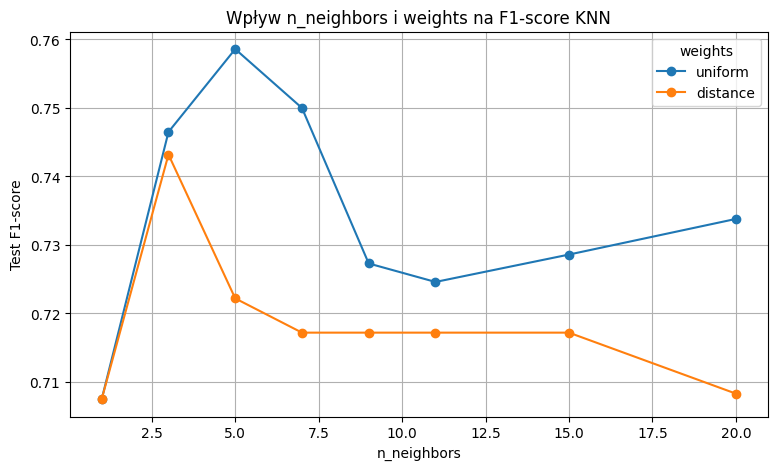

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

neighbors_values = [1, 3, 5, 7, 9, 11, 15, 20]

knn_results = []

for weight in ['uniform', 'distance']:

    for k in neighbors_values:

        model = KNeighborsClassifier(
            n_neighbors=k,
            weights=weight,
            metric='euclidean'
        )

        results = evaluate_model(
            model,
            X_train_scaled,
            y_train,
            X_test_scaled,
            y_test
        )

        results['n_neighbors'] = k
        results['weights'] = weight

        knn_results.append(results)

knn_df = pd.DataFrame(knn_results)

plt.figure(figsize=(9, 5))

for weight in ['uniform', 'distance']:
    data = knn_df[knn_df['weights'] == weight]

    plt.plot(
        data['n_neighbors'],
        data['Test F1'],
        marker='o',
        label=weight
    )

plt.xlabel('n_neighbors')
plt.ylabel('Test F1-score')
plt.title('Wpływ n_neighbors i weights na F1-score KNN')
plt.legend(title='weights')
plt.grid(True)
plt.show()

**Decision Tree**

Dla drzewa decyzyjnego zbadano wpływ `max_depth` oraz `min_samples_split`.

`max_depth` ogranicza maksymalną głębokość drzewa, natomiast `min_samples_split` określa minimalną liczbę próbek wymaganą do wykonania kolejnego podziału. Parametry te mają szczególne znaczenie w tym przypadku, ponieważ początkowy model wykazał wyraźną różnicę pomiędzy wynikami treningowymi i testowymi.

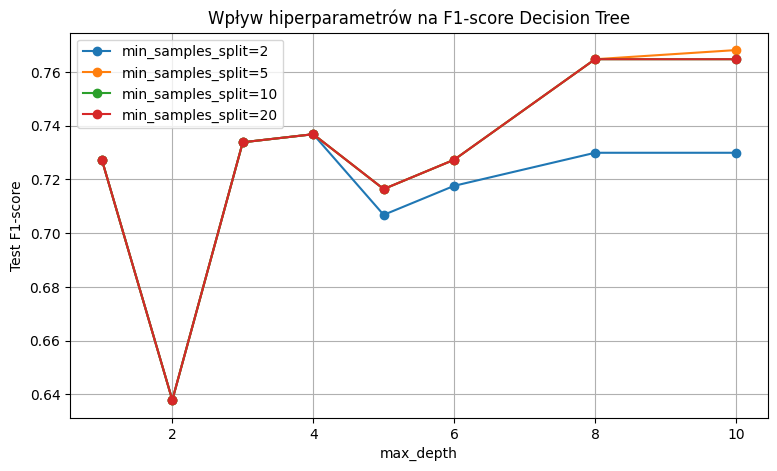

In [185]:
from sklearn.tree import DecisionTreeClassifier

max_depth_values = [1, 2, 3, 4, 5, 6, 8, 10]
min_samples_split_values = [2, 5, 10, 20]

tree_results = []

for depth in max_depth_values:

    for min_split in min_samples_split_values:

        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=min_split,
            random_state=42
        )

        results = evaluate_model(
            model,
            X_train,
            y_train,
            X_test,
            y_test
        )

        results['max_depth'] = depth
        results['min_samples_split'] = min_split

        tree_results.append(results)

tree_df = pd.DataFrame(tree_results)

plt.figure(figsize=(9, 5))

for min_split in min_samples_split_values:
    data = tree_df[tree_df['min_samples_split'] == min_split]

    plt.plot(
        data['max_depth'],
        data['Test F1'],
        marker='o',
        label=f'min_samples_split={min_split}'
    )

plt.xlabel('max_depth')
plt.ylabel('Test F1-score')
plt.title('Wpływ hiperparametrów na F1-score Decision Tree')
plt.legend()
plt.grid(True)
plt.show()

## Podsumowanie



**Porównanie modeli**

In [186]:
best_knn = knn_df.loc[knn_df['Test F1'].idxmax()]
best_tree = tree_df.loc[tree_df['Test F1'].idxmax()]

comparison_df = pd.DataFrame({
    'Dummy': dummy_results,
    'KNN': best_knn,
    'Decision Tree': best_tree
}).T

comparison_df

,Test F1,Test accuracy,Test precision,Test recall,Train F1,Train accuracy,max_depth,min_samples_split,n_neighbors,weights
Dummy,0.0,0.5866,0.0,0.0,0.0,0.6236,NaN,NaN,NaN,NaN
KNN,0.7586,0.8045,0.7746,0.7432,0.8047,0.861,NaN,NaN,5,uniform
Decision Tree,0.7681,0.8212,0.8281,0.7162,0.8554,0.9017,10.0,5.0,NaN,NaN


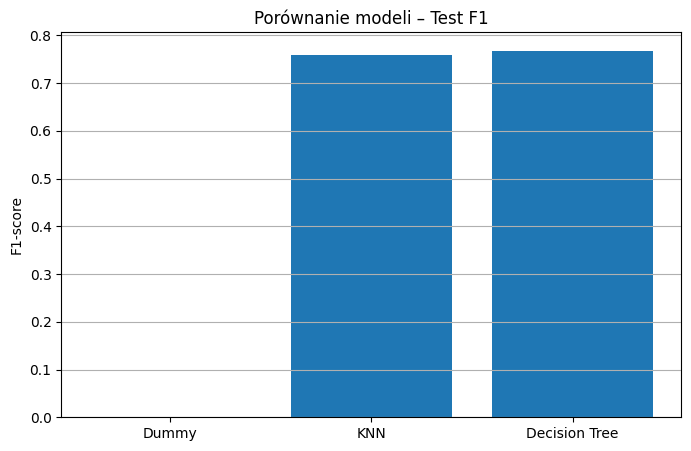

In [187]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df.index,
    comparison_df['Test F1']
)

plt.ylabel('F1-score')
plt.title('Porównanie modeli – Test F1')
plt.grid(axis='y')

plt.show()

**Wnioski końcowe**

Najlepszym modelem okazało się Decision Tree z `max_depth=10` i `min_samples_split=5`, które osiągnęło Test F1 równy 0.7681 oraz accuracy 0.8212. KNN z `n_neighbors=5` i `weights='uniform'` uzyskał bardzo zbliżone wyniki – Test F1 na poziomie 0.7586 i accuracy 0.8045. Oba modele wyraźnie przewyższyły Dummy Classifier, którego F1-score wyniósł 0, co pokazuje, że nauczyły się zależności występujących w danych. Różnica pomiędzy wynikami KNN i Decision Tree jest niewielka, dlatego przy innych podziałach danych modele mogą wymieniać się najlepszym wynikiem. Strojenie hiperparametrów pozwoliło również ograniczyć przeuczenie, szczególnie w przypadku drzewa decyzyjnego.